In [1]:
import scanpy as sc 
import muon as mu 
import numpy as np 
import pandas as pd 

In [2]:
mdata = mu.read_h5mu("/home/rsun@ZHANGroup.local/solid-recover/data/multi_omics/hca_brain_dev/train.h5mu")
mdata

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 116212 × 159101
  var:	'n_cells'
  2 modalities
    rna_count:	116212 x 17701
      obs:	'Sample_ID', 'Estimated_postconceptional_age_in_days', 'Group', 'Region', 'nCount_RNA', 'nFeature_RNA', 'ATAC_fragments_in_peaks', 'Percentage_reads_in_peaks', 'TSS.enrichment', 'Nucleosome_signal', 'Scrublet_doublet_score', 'S.Score', 'G2M.Score', 'Class', 'Subclass', 'Type', 'Type_updated', 'Cluster', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
      var:	'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
      uns:	'Type_colors', 'Type_updated_colors', 'citation', 'default_embedding', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
      obsm:	'X_embed_sr_ckpt_10000', 'X_embed_sr_ckpt_2000', 'X_embed_sr_ckpt_4000', 'X_embed_sr_ckpt_6000', 'X_embed_sr_ckpt_8000', 'X_pca', 'X_umap', 'X_umap_sr_ckpt_10000', 'X_umap_sr_ckpt_2000', 'X_umap_sr_ckpt_4000', 'X_umap_sr_ckpt_6000', 'X_umap_sr_ckpt_8000'
    atac_count:	116212 x 141400
      obs:	'n_fragment', 'frac_dup', 'frac_mito', 'cell_type', 'Type_updated'
      var:	'n_cells'
      uns:	'log1p'
      obsm:	'X_embed_sr_ckpt_10000', 'X_embed_sr_ckpt_2000', 'X_embed_sr_ckpt_4000', 'X_embed_sr_ckpt_6000', 'X_embed_sr_ckpt_8000'

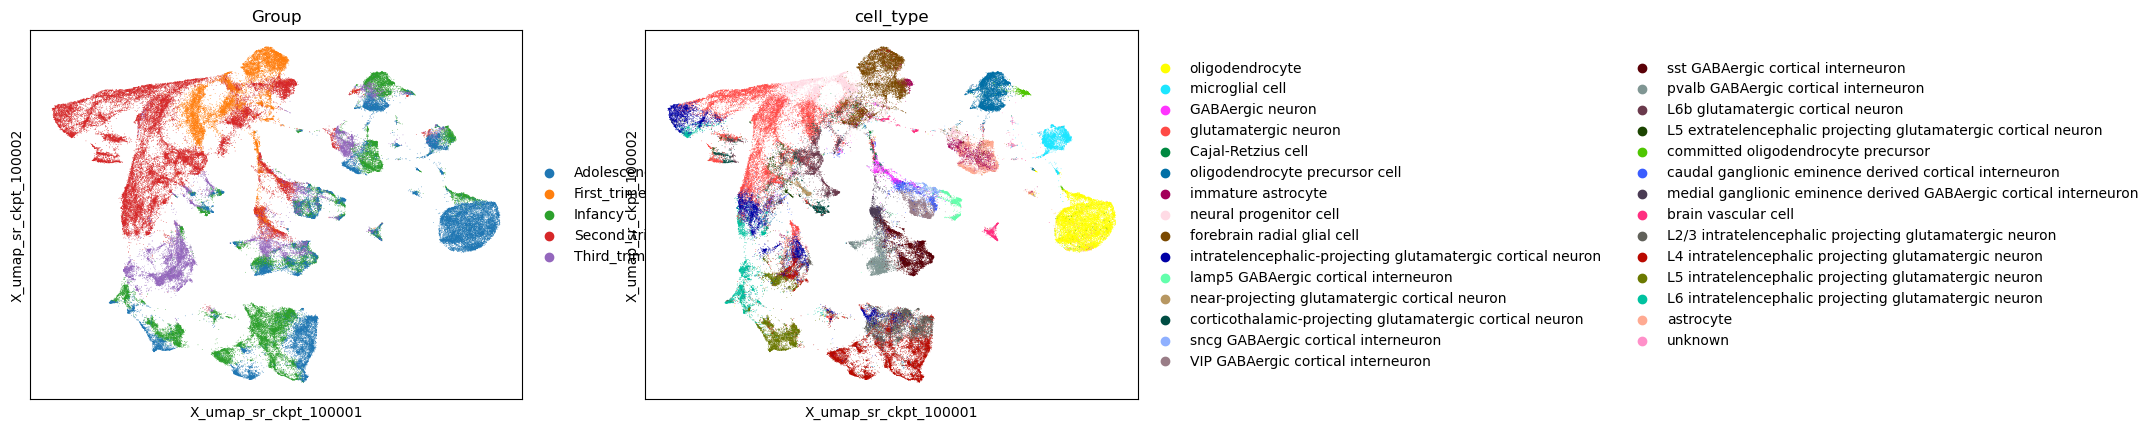

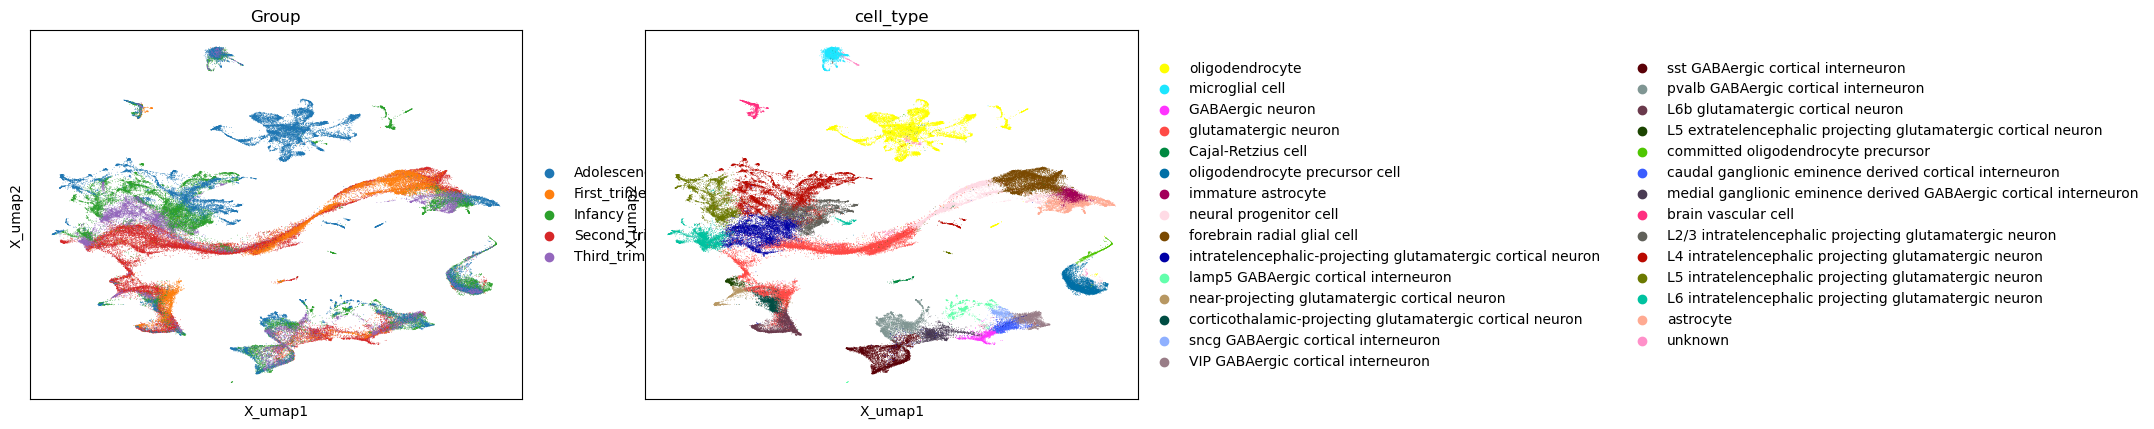

In [3]:
rna = mdata['rna_count']
rna.obsm['X_embed_sr_ckpt_10000'] = np.load('/home/rsun@ZHANGroup.local/solid_recover_dev/reports/round_3_CVAE_large/embeddings/train/ckpt_10000_z_mu_1.npy')
rna.obsm['X_umap_sr_ckpt_10000'] = np.load('/home/rsun@ZHANGroup.local/solid_recover_dev/reports/round_3_CVAE_large/umap/train/ckpt_10000/umap_coords.npy')
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_10000', color = ['Group','cell_type',])
sc.pl.embedding(rna, basis = 'X_umap', color = ['Group','cell_type',])

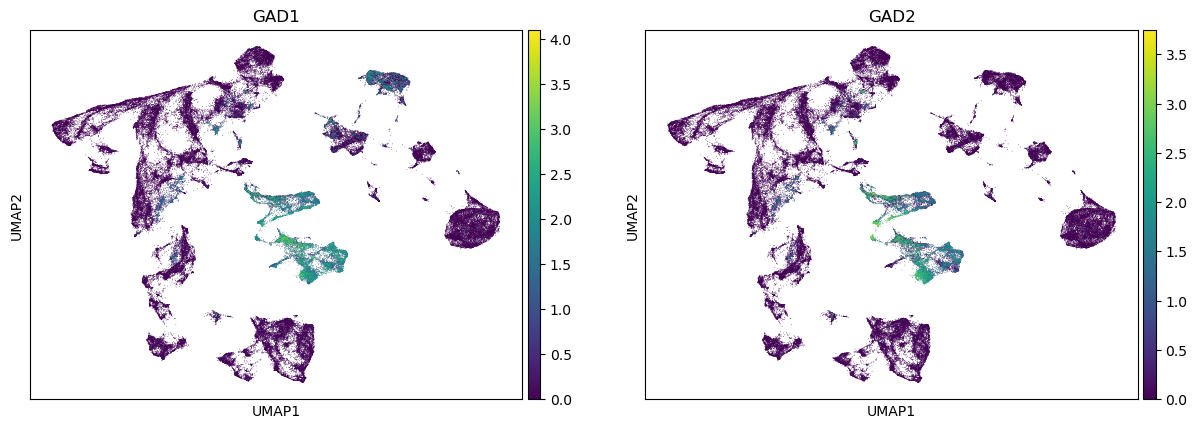

In [16]:
# rna.var.index = rna.var.gene_name
sc.pl.umap(rna, color = ['GAD1','GAD2'])

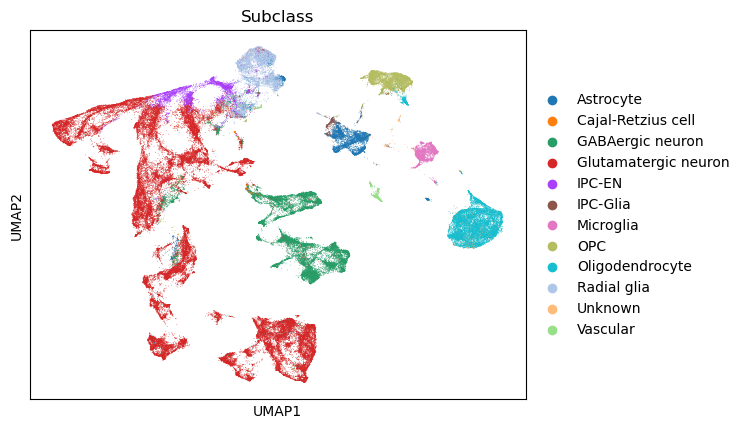

In [17]:
#sc.pp.neighbors(rna, use_rep = 'X_embed_sr_ckpt_10000')#, n_neighbors = 50)
# sc.tl.umap(rna, min_dist = 0.1)
sc.pl.umap(rna,  color = ['Subclass',])

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes

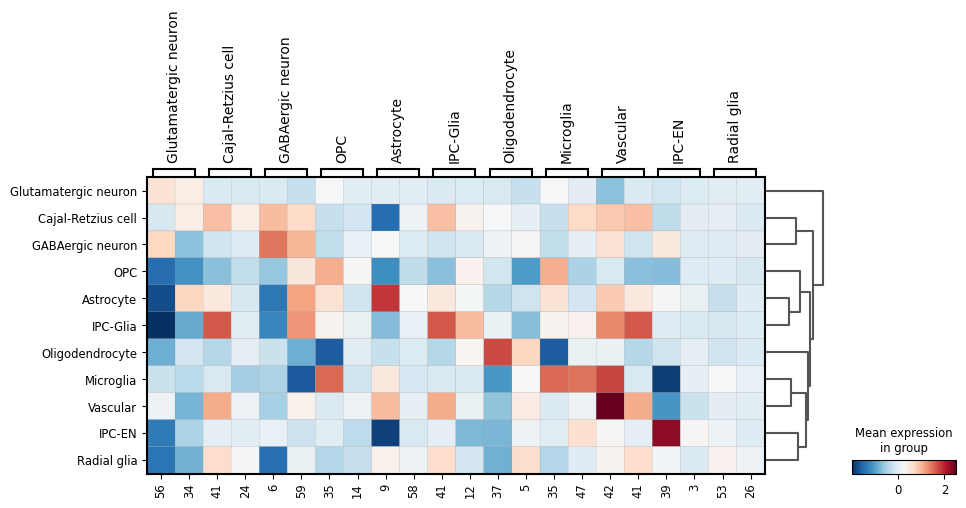

In [20]:
import anndata as ad

# embed = rna.obsm['X_embed_sr_ckpt_10000'].copy()
# adata = ad.AnnData(embed, obs = rna.obs.copy())
# idx = adata.obs.Subclass == 'Unknown'
# adata = adata[~idx,:]
# sc.pp.scale(adata)
sc.tl.rank_genes_groups(adata, groupby = 'Subclass', mehod = 'logreg')
sc.pl.rank_genes_groups_matrixplot(adata, groupby = 'Subclass', cmap = 'RdBu_r', n_genes = 2)#,vmin = -2,vmax = 2)


In [ ]:
import seaborn as sns  
import matplotlib.pyplot as plt  

embed = rna.obsm['X_embed_sr_ckpt_8000'].copy()
df = pd.DataFrame(embed)
df.loc[:,'Subclass'] = rna.obs.Subclass.values  

df_mean = df.groupby('Subclass').mean()

sns.clustermap(df_mean, cmap = 'coolwarm',figsize = (15,6),vmin = -2)
plt.show()

In [ ]:
rna

In [ ]:
sc.pp.neighbors(rna, use_rep = 'X_embed_sr_ckpt_10000', n_neighbors = 50)
sc.tl.umap(rna, min_dist = 0.4)
sc.pl.umap(rna,  color = ['Group','cell_type',])

In [ ]:
idx = rna.obs.celltype_final.isin(['PT','PT(S1)','PT(S2)','PT(S3)'])
rna = rna[idx,:]
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_2000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_4000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_6000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_8000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_10000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap', color = ['sex','celltype_final'])

In [ ]:
sc.pp.neighbors(rna )
sc.tl.umap(rna, min_dist = 0.5)
sc.pl.umap(rna, color = ['sex','celltype_final'])

In [ ]:
sc.pp.neighbors(rna, use_rep = 'X_embed_sr_ckpt_10000', metric = 'cosine')
sc.tl.umap(rna, min_dist = 0.5)
sc.pl.umap(rna, color = ['sex','celltype_final'])

In [ ]:
sc.pp.neighbors(rna, use_rep = 'X_embed_sr_ckpt_10000')
sc.tl.umap(rna, min_dist = 0.5)
sc.pl.umap(rna, color = ['sex','celltype_final'])

In [ ]:
sc.pl.umap(rna, color = ['Age','donor_id'])

In [ ]:
for ckpt in [2000,4000,6000,8000,10000]:
    rna.obs.sex == 'female'
    mu_1 = rna[idx,:].obsm[f'X_embed_sr_ckpt_{ckpt}'].mean(axis = 0)
    mu_2 = rna[~idx,:].obsm[f'X_embed_sr_ckpt_{ckpt}'].mean(axis = 0)
    plt.scatter(x=mu_1, y=mu_2)
    plt.xlabel('female mu')
    plt.ylabel('male mu')

    # 添加 y=x 参考线
    min_val = min(mu_1.min(), mu_2.min())
    max_val = max(mu_1.max(), mu_2.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='y=x')
    plt.legend()

    plt.show()

In [ ]:
adata = mdata['rna_count']
idx = adata.obs.celltype_final.isin(['PT','PT(S1)','PT(S2)','PT(S3)'])
adata = adata[idx,:]
sc.pl.umap(adata, color = ['Age','donor_id'])